# Visium Thymus Flash Analysis Pipeline

This notebook analyzes spatial transcriptomics data from a Visium Thymus Flash experiment.

- **Reusable functions** are imported from the `spatial_transcriptomics` package for configuration, data loading, QC, analysis, and plotting.
- **Analysis-specific decisions** remain documented in the notebook for this experiment.
- **Current scope:** load FD1 at 8 µm, attach spatial coordinates, and inspect unfiltered QC. Filtering, normalization, clustering, and downstream analysis are intentionally deferred.

## Experimental context and input requirements

For each tissue section, the Space Ranger output should provide:

- a filtered feature-barcode matrix;
- spatial coordinates and scale factors;
- tissue images;
- bin- or cell-level metadata.

The project sample sheet should eventually record at least `sample_id`, `mouse_id`, `condition` (`control`, `conv`, or `flash`), `timepoint`, the Space Ranger source path, and the selected bin size. Histology-informed ROI labels, section-quality notes, and a matching scRNA-seq thymus reference for later deconvolution are also recommended.

Raw FD1–FD12 sample folders remain under `/oak/stanford/groups/dirbas/Angela/thymus_9h/raw_data/`. Processed results go to `/labs/dirbas/acorvino/thymus_9h/processed_data/`. Both storage allocations are hosted on Oak. These paths are configured in `configs/cluster.yaml`. The batch QC script saves reports under the `/labs` results root in `qc/visium_hd_008um/`; this notebook displays its outputs interactively. Updating the configuration does not relocate existing results; see `cluster/README.md` for copying them while preserving QC caches.

For the current FD1 pass, `raw_data/FD1/binned_outputs.tar.gz` remains unchanged on Oak and only `square_008um` is extracted into job-local SCG scratch. The expected staged directory is `${TMPDIR}/FD1_HD/binned_outputs/square_008um/`, containing `filtered_feature_bc_matrix.h5` and `spatial/tissue_positions.parquet`. "Unfiltered QC" here means no additional repository-level filtering after Space Ranger's filtered matrix.

## 1. Setup and configuration

The default is the SCG configuration. Set `SPATIAL_CONFIG` before starting Jupyter to select a different config.

In [1]:
import sys
print(sys.executable)

/home/acorvino/.envs/python-env/bin/python


## 1. Setup and configuration

The default is the SCG configuration. Set `SPATIAL_CONFIG` before starting Jupyter to select a different config.

In [ ]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
from scipy import sparse

from spatial_transcriptomics.config import (
    get_config_section,
    get_section_path,
    load_config,
)
from spatial_transcriptomics.data import (
    calc_qc_metrics,
    load_reference_genes,
    load_visium_hd_bin,
)

from spatial_transcriptomics.plotting import plot_hd_spatial

sc.settings.verbosity = 2
sc.settings.set_figure_params(dpi=100, facecolor="white")

config_path = os.environ.get("SPATIAL_CONFIG", "configs/cluster.yaml")
config = load_config(config_path)
repo_root = Path(str(config["repo_root"]))
hd_config = get_config_section(config, "visium_hd")
sample_id = str(hd_config.get("sample_id", "FD_1"))
bin_size_um = int(hd_config.get("bin_size_um", 8))
staged_dir = get_section_path(
    config, hd_config, "staged_dir", "${TMPDIR}/FD1_HD"
)
load_images = bool(hd_config.get("load_images", True))
use_filtered_matrix = bool(hd_config.get("use_filtered_matrix", True))

print(f"Config: {config_path}")
print(f"Sample: {sample_id}; bin size: {bin_size_um} µm")
print(f"Raw input: {hd_config.get('source_dir', config['data_dir'])}")
print(f"Results root: {config['output_dir']}")
print(f"Staged input: {staged_dir}")
print(f"TMPDIR: {os.environ.get('TMPDIR', '<not set>')}")

## 2. Stage and validate the input

The configured scratch directory may be empty in a new SCG OnDemand job. If either required QC file is missing, extract the selected matrix and positions from `visium_hd.source_dir/binned_outputs.tar.gz` into `visium_hd.staged_dir`. The archive stays unchanged on Oak; extraction can take several minutes. Rerunning this cell reuses complete staged inputs. This QC staging step does not extract tissue images or scale factors; the loader uses them only if already staged. Rerun setup first when starting a new session so paths use its current `TMPDIR`.

In [ ]:
from spatial_transcriptomics.data import stage_visium_hd_qc

bin_name = f"square_{bin_size_um:03d}um"
bin_dir = staged_dir / "binned_outputs" / bin_name
matrix_name = (
    "filtered_feature_bc_matrix.h5"
    if use_filtered_matrix else "raw_feature_bc_matrix.h5"
)
matrix_path = bin_dir / matrix_name
positions_path = bin_dir / "spatial" / "tissue_positions.parquet"
required_paths = [matrix_path, positions_path]
missing = [path for path in required_paths if not path.is_file()]
if missing:
    source_dir = get_section_path(config, hd_config, "source_dir", "data/FD1")
    archive_path = source_dir / "binned_outputs.tar.gz"
    if not archive_path.is_file():
        missing_text = "\n".join(f"- {path}" for path in missing)
        raise FileNotFoundError(
            f"Staged QC inputs are missing:\n{missing_text}\n"
            f"Source archive also not found: {archive_path}\n"
            "Check visium_hd.source_dir in the selected config and Oak access "
            "from this Jupyter session."
        )
    print(f"Staging {bin_size_um} µm QC inputs from {archive_path}", flush=True)
    print(f"Destination: {staged_dir}", flush=True)
    stage_visium_hd_qc(
        archive_path,
        staged_dir,
        bin_size_um=bin_size_um,
        use_filtered_matrix=use_filtered_matrix,
    )

missing = [path for path in required_paths if not path.is_file()]
if missing:
    raise FileNotFoundError(f"Staging did not produce the required inputs: {missing}")
print(f"Required {bin_size_um} µm inputs found:")
for path in required_paths:
    print(f"- {path}")

## 3. Load matrix and spatial coordinates

The matrix remains sparse. No filtering, normalization, scaling, PCA, or clustering is performed.

In [4]:
adata = load_visium_hd_bin(
    staged_dir,
    bin_size_um=bin_size_um,
    library_id=sample_id,
    load_images=load_images,
    use_filtered_matrix=use_filtered_matrix,
)

print(adata)
print(f"Bins: {adata.n_obs:,}")
print(f"Features: {adata.n_vars:,}")
print(f"Sparse count matrix: {sparse.issparse(adata.X)}")
print(f"Spatial coordinate shape: {adata.obsm['spatial'].shape}")
print(f"Spatial libraries: {list(adata.uns.get('spatial', {}))}")

reading /local/scratch/acorvino/slrmtmp.52497336/FD1_HD/binned_outputs/square_008um/filtered_feature_bc_matrix.h5
 (0:00:01)


/home/acorvino/.envs/python-env/lib/python3.11/site-packages/anndata/_core/anndata.py:1884: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/acorvino/.envs/python-env/lib/python3.11/site-packages/anndata/_core/anndata.py:1884: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


AnnData object with n_obs × n_vars = 133249 × 19070
    obs: 'in_tissue', 'array_row', 'array_col', 'pxl_row_in_fullres', 'pxl_col_in_fullres', 'bin_size_um'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial', 'visium_hd'
    obsm: 'spatial'
Bins: 133,249
Features: 19,070
Sparse count matrix: True
Spatial coordinate shape: (133249, 2)
Spatial libraries: ['FD_1']


## 4. Calculate unfiltered QC metrics

Metrics are calculated on the Space Ranger filtered matrix. No additional bins are removed. The repository's conventional-Visium thresholds are deliberately not applied.

In [5]:
mt_genes = load_reference_genes(
    repo_root / "reference_genomes" / "mouse_mitochondrial_genes.txt"
)
rp_genes = load_reference_genes(
    repo_root / "reference_genomes" / "mouse_ribosomal_genes.txt"
)
adata = calc_qc_metrics(adata, mt_genes=mt_genes, rp_genes=rp_genes)

qc_columns = [
    column
    for column in [
        "total_counts",
        "n_genes_by_counts",
        "pct_counts_mt",
        "pct_counts_rp",
    ]
    if column in adata.obs
]
qc_summary = adata.obs[qc_columns].describe(
    percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
).T
qc_summary

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
total_counts,133249.0,116.706688,88.304688,0.0,0.0,5.0,51.0,101.000000,165.000000,286.0,386.00000,843.0
n_genes_by_counts,133249.0,108.690069,80.384503,0.0,0.0,5.0,48.0,95.000000,153.000000,263.0,351.00000,709.0
pct_counts_mt,133249.0,2.189300,4.929977,0.0,0.0,0.0,0.0,0.896861,2.040816,10.0,24.42322,100.0


## 5. Inspect QC distributions

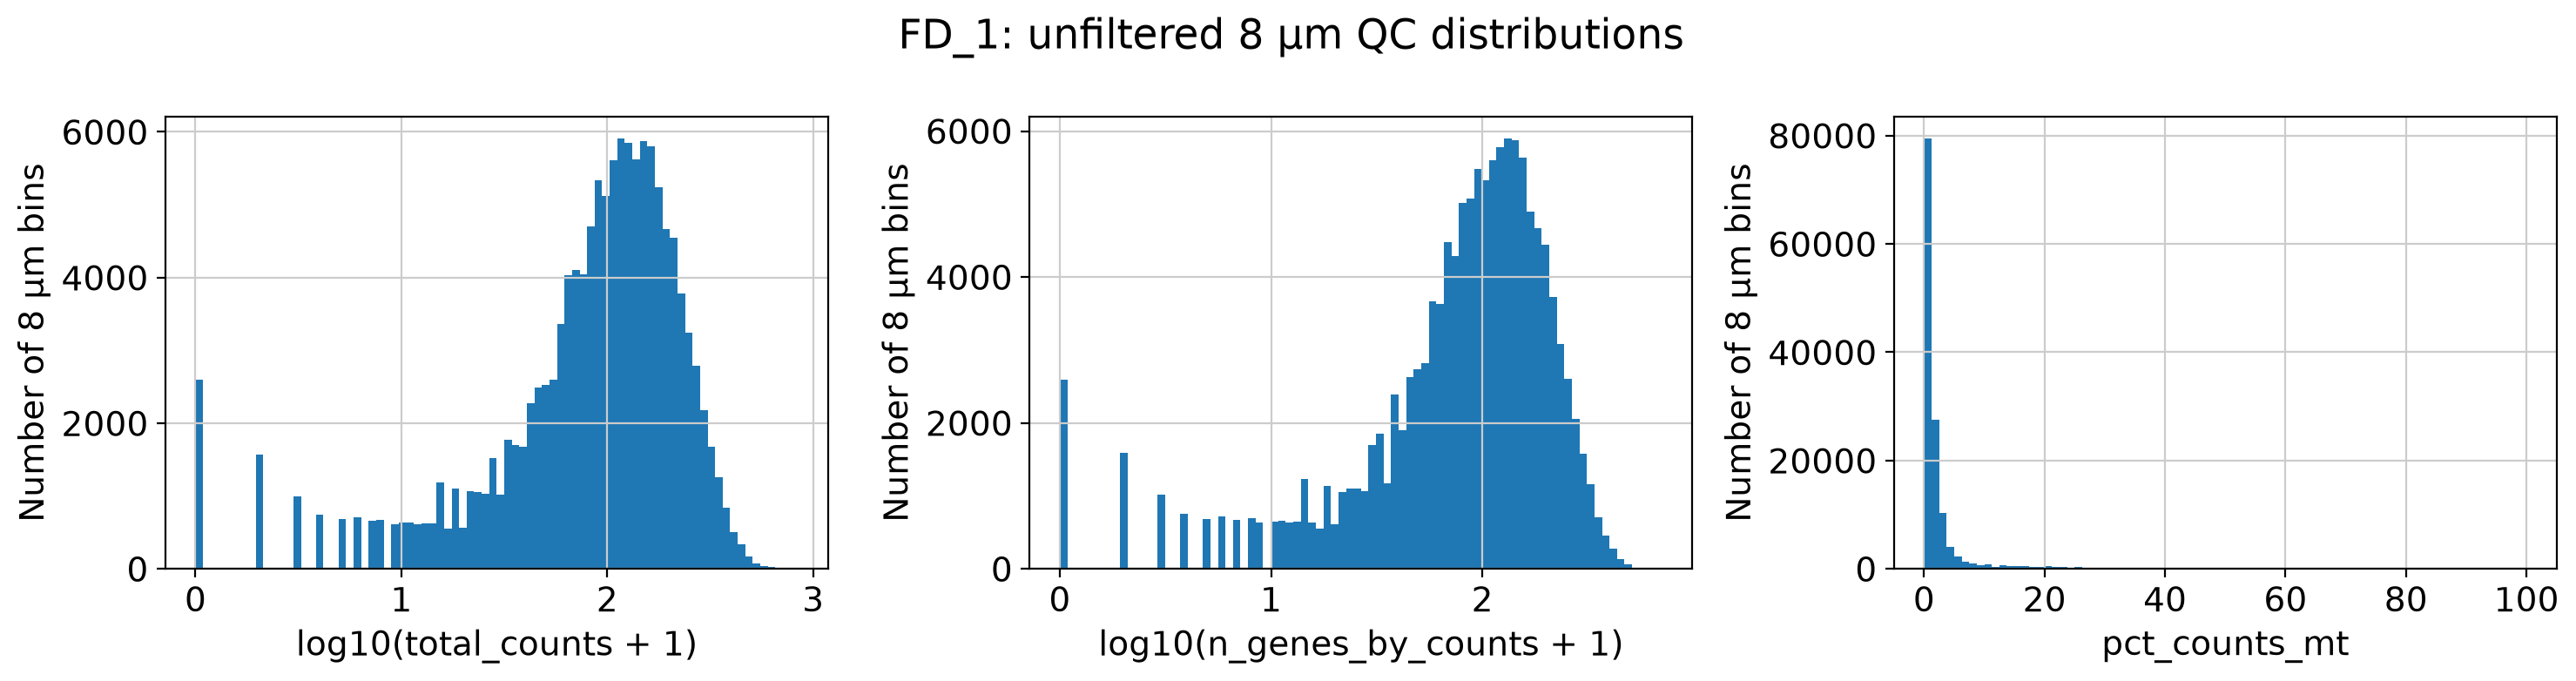

In [6]:
fig, axes = plt.subplots(1, len(qc_columns), figsize=(5 * len(qc_columns), 4))
if len(qc_columns) == 1:
    axes = [axes]

for ax, column in zip(axes, qc_columns):
    values = adata.obs[column].to_numpy()
    if column in {"total_counts", "n_genes_by_counts"}:
        values = np.log10(values + 1)
        xlabel = f"log10({column} + 1)"
    else:
        xlabel = column
    ax.hist(values, bins=80)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Number of 8 µm bins")

fig.suptitle(f"{sample_id}: unfiltered 8 µm QC distributions")
plt.tight_layout()
plt.show()

## 6. Inspect QC metrics in spatial coordinates

In [ ]:
coordinates = adata.obsm["spatial"]
spatial_qc = pd.DataFrame(
    {"x": coordinates[:, 0], "y": coordinates[:, 1]},
    index=adata.obs_names,
)
spatial_metrics = ["total_counts", "n_genes_by_counts"]
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, metric in zip(axes, spatial_metrics):
    values = np.log1p(adata.obs[metric].to_numpy())
    points = plot_hd_spatial(
        ax, spatial_qc, np.ones(adata.n_obs, dtype=bool), values
    )
    ax.set_title(f"log1p({metric})")
    fig.colorbar(points, ax=ax, shrink=0.7)

fig.suptitle(f"{sample_id}: unfiltered spatial QC at {bin_size_um} µm")
plt.tight_layout()
plt.show()


## 7. Evaluate candidate QC thresholds

The 8 µm bins are much shallower than conventional/older Visium spots(55 um) for which "min_counts": 500, "min_genes": 250. In our case the median bin has 101 counts and 95 detected genes so we need to choose a threshold accordingly. This step compares candidate thresholds without changing `adata`. The conventional-Visium settings are included only as a reference so that their effect is explicit.

In [ ]:
import pandas as pd

candidate_filters = [
    {"candidate": "No additional filter", "min_counts": 0, "min_genes": 0, "max_pct_mt": 100.0},
    {"candidate": "Lenient 8 µm", "min_counts": 10, "min_genes": 10, "max_pct_mt": 25.0},
    {"candidate": "Moderate 8 µm", "min_counts": 25, "min_genes": 20, "max_pct_mt": 20.0},
    {"candidate": "Higher-content 8 µm", "min_counts": 50, "min_genes": 40, "max_pct_mt": 20.0}
]

counts = adata.obs["total_counts"].to_numpy()
genes = adata.obs["n_genes_by_counts"].to_numpy()
pct_mt = adata.obs["pct_counts_mt"].to_numpy()
total_transcripts = counts.sum()
candidate_masks = {}
candidate_rows = []

for candidate in candidate_filters:
    mask = (
        (counts >= candidate["min_counts"])
        & (genes >= candidate["min_genes"])
        & (pct_mt <= candidate["max_pct_mt"])
    )
    candidate_masks[candidate["candidate"]] = mask
    retained_counts = counts[mask]
    retained_genes = genes[mask]
    candidate_rows.append(
        {
            **candidate,
            "bins_retained": int(mask.sum()),
            "bins_retained_pct": 100 * mask.mean(),
            "transcripts_retained_pct": (
                100 * retained_counts.sum() / total_transcripts
                if total_transcripts else 0.0
            ),
            "median_counts_retained": (
                float(np.median(retained_counts)) if mask.any() else np.nan
            ),
            "median_genes_retained": (
                float(np.median(retained_genes)) if mask.any() else np.nan
            ),
        }
    )

candidate_summary = pd.DataFrame(candidate_rows).set_index("candidate")
candidate_summary.round(2)

### Spatial retention under candidate thresholds

Compare the retained-bin footprint before choosing a threshold. A suitable filter should remove isolated low-information bins without erasing coherent tissue regions.

In [ ]:
candidates_to_plot = [
    "No additional filter",
    "Lenient 8 µm",
    "Moderate 8 µm",
    "Higher-content 8 µm",
]

fig, axes = plt.subplots(2, 2, figsize=(14, 12), constrained_layout=True)
for ax, label in zip(axes.flat, candidates_to_plot):
    mask = candidate_masks[label]
    plot_hd_spatial(ax, spatial_qc, mask, np.log1p(counts))
    ax.set_title(
        f"{label}\n{mask.sum():,} bins retained ({100 * mask.mean():.1f}%)"
    )

fig.suptitle(f"{sample_id}: candidate QC retention at {bin_size_um} µm")
plt.show()


## Decision checkpoint

Review the retention table and spatial footprints before applying a filter. This section intentionally leaves `adata` unchanged. Record the selected thresholds and rationale before creating a filtered AnnData object.

## 8. Validate candidate thresholds across mice

A threshold chosen from FD1 alone could favor that mouse's library depth or tissue quality. Start by comparing FD1 with FD2 at the same 8 µm resolution. The code processes one mouse at a time, retains only compact QC arrays for plotting, and leaves every AnnData object unfiltered. After the two-mouse check succeeds, change `comparison_mouse_ids` to `available_mouse_ids` to evaluate all 12 mice before fixing a shared threshold.

In [ ]:
import gc
import subprocess

from IPython.display import display

available_mouse_ids = [f"FD{i}" for i in range(1, 13)]
comparison_mouse_ids = ["FD1", "FD2"]
# For the final cross-mouse evaluation, use:
# comparison_mouse_ids = available_mouse_ids

source_root = Path(str(hd_config["source_dir"])).parent
comparison_stage_root = Path(os.environ["TMPDIR"]) / "visium_hd_cross_mouse_qc"
comparison_stage_root.mkdir(parents=True, exist_ok=True)
current_mouse_id = Path(str(hd_config["source_dir"])).name

def stage_comparison_mouse(mouse_id):
    archive_path = source_root / mouse_id / "binned_outputs.tar.gz"
    if not archive_path.is_file():
        raise FileNotFoundError(
            f"Archive not found for {mouse_id}: {archive_path}"
        )

    staged_mouse_dir = comparison_stage_root / f"{mouse_id}_HD"
    staged_mouse_dir.mkdir(parents=True, exist_ok=True)

    def find_matrix():
        return [
            path
            for path in staged_mouse_dir.rglob(
                "filtered_feature_bc_matrix.h5"
            )
            if path.parent.name == bin_name
        ]

    matrix_paths = find_matrix()

    if not matrix_paths:
        print(f"Staging {mouse_id} {bin_size_um} µm data from Oak...")
        subprocess.run(
            [
                "tar",
                "--extract",
                "--gzip",
                f"--file={archive_path}",
                f"--directory={staged_mouse_dir}",
                "--wildcards",
                "--wildcards-match-slash",
                "--no-anchored",
                f"{bin_name}/*",
            ],
            check=True,
        )
        matrix_paths = find_matrix()

    if len(matrix_paths) != 1:
        raise FileNotFoundError(
            f"Expected one {bin_name} matrix for {mouse_id}, "
            f"but found: {matrix_paths}"
        )

    return matrix_paths[0].parent

print(f"Source root: {source_root}")
print(f"Comparison mice: {comparison_mouse_ids}")
print(f"Scratch staging root: {comparison_stage_root}")

In [ ]:
cross_mouse_qc_rows = []
cross_mouse_candidate_rows = []
cross_mouse_plot_data = {}

for mouse_id in comparison_mouse_ids:
    print(f"Processing {mouse_id}...")
    if mouse_id == current_mouse_id:
        sample_adata = adata
    else:
        sample_staged_dir = stage_comparison_mouse(mouse_id)
        sample_adata = load_visium_hd_bin(
            sample_staged_dir,
            bin_size_um=bin_size_um,
            library_id=mouse_id,
            load_images=False,
            use_filtered_matrix=use_filtered_matrix,
        )
        sample_adata = calc_qc_metrics(
            sample_adata, mt_genes=mt_genes, rp_genes=rp_genes
        )

    sample_counts = sample_adata.obs["total_counts"].to_numpy()
    sample_genes = sample_adata.obs["n_genes_by_counts"].to_numpy()
    sample_pct_mt = sample_adata.obs["pct_counts_mt"].to_numpy()
    sample_coordinates = sample_adata.obsm["spatial"].copy()
    sample_total_transcripts = sample_counts.sum()
    mt_matches = sum(gene in sample_adata.var_names for gene in mt_genes)
    rp_matches = sum(gene in sample_adata.var_names for gene in rp_genes)

    cross_mouse_qc_rows.append(
        {
            "mouse_id": mouse_id,
            "bins": sample_adata.n_obs,
            "median_counts": np.median(sample_counts),
            "counts_p05": np.percentile(sample_counts, 5),
            "counts_p95": np.percentile(sample_counts, 95),
            "median_genes": np.median(sample_genes),
            "genes_p05": np.percentile(sample_genes, 5),
            "genes_p95": np.percentile(sample_genes, 95),
            "median_pct_mt": np.median(sample_pct_mt),
            "pct_mt_p95": np.percentile(sample_pct_mt, 95),
            "pct_mt_p99": np.percentile(sample_pct_mt, 99),
            "mt_genes_matched": mt_matches,
            "rp_genes_matched": rp_matches,
        }
    )

    sample_masks = {}
    for candidate in candidate_filters:
        mask = (
            (sample_counts >= candidate["min_counts"])
            & (sample_genes >= candidate["min_genes"])
            & (sample_pct_mt <= candidate["max_pct_mt"])
        )
        sample_masks[candidate["candidate"]] = mask
        cross_mouse_candidate_rows.append(
            {
                "mouse_id": mouse_id,
                **candidate,
                "bins_retained": int(mask.sum()),
                "bins_retained_pct": 100 * mask.mean(),
                "transcripts_retained_pct": (
                    100 * sample_counts[mask].sum() / sample_total_transcripts
                    if sample_total_transcripts else 0.0
                ),
            }
        )

    cross_mouse_plot_data[mouse_id] = {
        "barcodes": sample_adata.obs_names.copy(),
        "coordinates": sample_coordinates,
        "counts": sample_counts.copy(),
        "masks": sample_masks,
    }
    if mouse_id != current_mouse_id:
        del sample_adata
        gc.collect()

cross_mouse_qc_summary = pd.DataFrame(cross_mouse_qc_rows).set_index("mouse_id")
cross_mouse_candidate_summary = pd.DataFrame(cross_mouse_candidate_rows)
display(cross_mouse_qc_summary.round(2))
display(
    cross_mouse_candidate_summary.set_index(["mouse_id", "candidate"]).round(2)
)

### Compare retention across mice

Large differences between mice indicate that a shared cutoff may introduce sample bias. Compare both bin retention and transcript retention: retaining fewer bins can still be reasonable if nearly all informative transcripts and coherent tissue regions remain.

In [ ]:
candidate_order = [candidate["candidate"] for candidate in candidate_filters]
short_labels = {
    "No additional filter": "None",
    "Lenient 8 µm": "Lenient",
    "Moderate 8 µm": "Moderate",
    "Higher-content 8 µm": "Higher-content",
}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharex=True)
for mouse_id in comparison_mouse_ids:
    mouse_summary = (
        cross_mouse_candidate_summary
        .loc[lambda frame: frame["mouse_id"] == mouse_id]
        .set_index("candidate")
        .reindex(candidate_order)
    )
    labels = [short_labels.get(label, label) for label in candidate_order]
    axes[0].plot(labels, mouse_summary["bins_retained_pct"], marker="o", label=mouse_id)
    axes[1].plot(labels, mouse_summary["transcripts_retained_pct"], marker="o", label=mouse_id)

axes[0].set_ylabel("Bins retained (%)")
axes[1].set_ylabel("Transcripts retained (%)")
for ax in axes:
    ax.set_ylim(0, 102)
    ax.grid(alpha=0.25)
    ax.tick_params(axis="x", rotation=25)
    ax.legend(title="Mouse")
fig.suptitle(f"Candidate QC retention across {bin_size_um} µm samples")
plt.tight_layout()
plt.show()

### Compare spatial retention for one candidate

Use this view to check whether the same candidate preserves coherent tissue in each mouse. Change `candidate_to_inspect` to compare the lenient or higher-content alternative. Gray bins would be removed; blue bins would be retained.

In [ ]:
candidate_to_inspect = "Moderate 8 µm"
fig, axes = plt.subplots(
    1, len(comparison_mouse_ids),
    figsize=(7 * len(comparison_mouse_ids), 6),
    squeeze=False,
    constrained_layout=True,
)

for ax, mouse_id in zip(axes.flat, comparison_mouse_ids):
    plot_data = cross_mouse_plot_data[mouse_id]
    sample_coordinates = plot_data["coordinates"]
    sample_spatial_qc = pd.DataFrame(
        {"x": sample_coordinates[:, 0], "y": sample_coordinates[:, 1]},
        index=plot_data["barcodes"],
    )
    mask = plot_data["masks"][candidate_to_inspect]
    plot_hd_spatial(ax, sample_spatial_qc, mask)
    ax.set_title(
        f"{mouse_id}: {mask.sum():,} bins retained ({100 * mask.mean():.1f}%)"
    )

fig.suptitle(f"{candidate_to_inspect}: spatial retention across mice")
plt.show()


## Cross-mouse decision checkpoint

Do not fix the final threshold from two mice alone. First confirm that FD1 and FD2 run successfully, then evaluate all 12 mice. A shared threshold is defensible only if retention is reasonably consistent and the spatial tissue footprint remains coherent across mice. If retention differs systematically, investigate library depth, tissue quality, and experimental condition before considering sample-specific thresholds.